# 고급 학습 기법

> 학습 데이터를 바꾸기 전에, 학습 방법을 바꿔라 — 같은 데이터도 학습 전략에 따라 완전히 다른 모델이 된다

파인튜닝만으로는 해결되지 않는 문제들이 있다. **도메인 지식 주입, 모델 결합, 모델 경량화, 학습 효율 극대화** 각각에 최적화된 기법이 존재한다.

---

### 학습 목표

| # | 목표 |
|---|------|
| 1 | **Continued Pre-training**과 Fine-tuning의 목적 차이를 이해하고 적용 시점을 판단한다 |
| 2 | **Model Merging** 기법(TIES, DARE, SLERP)의 원리와 적합 상황을 구분한다 |
| 3 | **Knowledge Distillation**에서 Temperature와 Soft Label의 역할을 설명한다 |
| 4 | **Curriculum Learning**의 난이도 제어 전략이 학습 효율에 미치는 영향을 실험한다 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

print("Phase 9-2: 고급 학습 기법")
print("  Continued Pre-training | Model Merging | Distillation | Curriculum Learning")

Phase 9-2: 고급 학습 기법
  Continued Pre-training | Model Merging | Distillation | Curriculum Learning


---
## 1. Continued Pre-training vs Fine-tuning

Fine-tuning은 **태스크 수행 방식**을 가르치고, Continued Pre-training은 **도메인 지식 자체**를 주입한다.  
의료, 법률, 금융 등 특수 도메인에서 모델이 기본 용어조차 모를 때 필요한 기법이다.

| 항목 | Continued Pre-training | Fine-tuning (SFT) |
|------|----------------------|-------------------|
| **목적** | 도메인 지식 주입 | 태스크 수행 능력 부여 |
| **데이터 형태** | 비구조화 텍스트 (논문, 문서, 코드) | 구조화된 instruction-response 쌍 |
| **데이터 양** | 수 GB ~ 수십 GB | 수천 ~ 수만 샘플 |
| **학습률** | 사전학습의 1/10 ~ 1/100 | 1e-5 ~ 5e-5 |
| **학습 기간** | 수일 ~ 수주 | 수시간 ~ 수일 |
| **Catastrophic Forgetting** | 높음 (일반 능력 손실) | 보통 |
| **결과** | 도메인 이해력 향상 | 지시 따르기 능력 향상 |
| **순서** | **먼저** 실행 | Continued PT **이후** 실행 |

### 실전 파이프라인

```
Base Model(범용) → Continued Pre-training(도메인 코퍼스) → Domain-adapted Model → SFT(태스크별) → DPO/RLHF(정렬) → 최종 모델
```

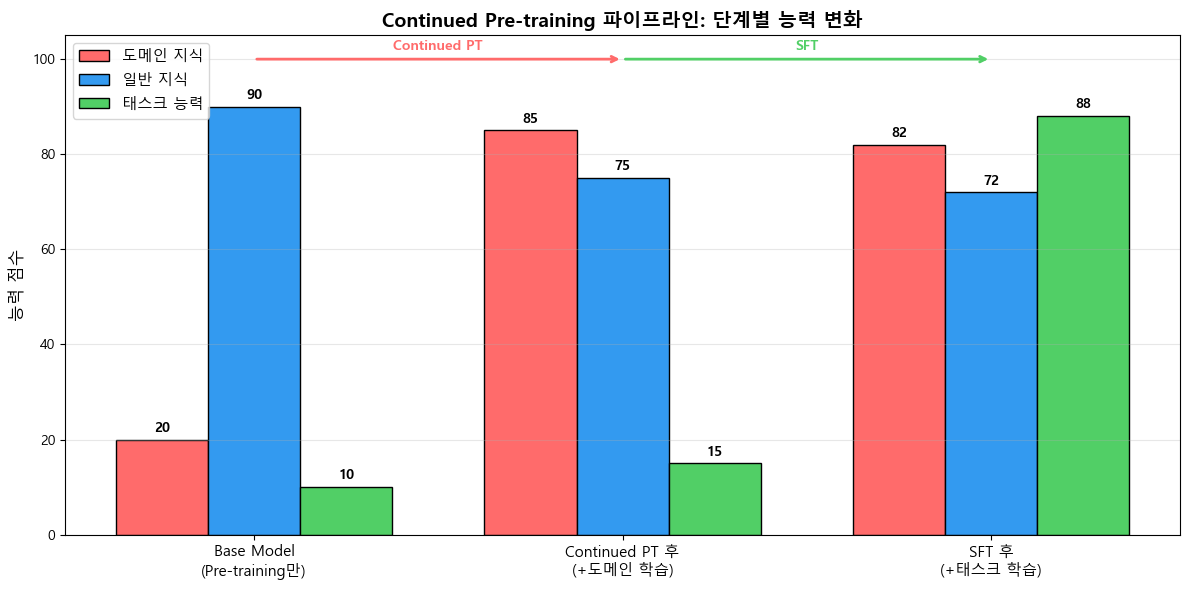

핵심 관찰:
  1. Continued PT → 도메인 지식 급상승 (20→85), 일반 지식 소폭 하락 (90→75)
  2. SFT → 태스크 능력 급상승 (15→88), 도메인/일반 지식은 거의 유지
  3. 순서가 중요: SFT를 먼저 하면 Continued PT 시 태스크 능력이 날아감


In [2]:
# === Continued Pre-training 파이프라인 시각화 ===
# 3단계 (Pre-training → Continued PT → SFT) 비교 bar chart

fig, ax = plt.subplots(figsize=(12, 6))

stages = ['Base Model\n(Pre-training만)', 'Continued PT 후\n(+도메인 학습)', 'SFT 후\n(+태스크 학습)']
x = np.arange(len(stages))
width = 0.25

# 각 단계별 능력 점수 (0~100)
domain_knowledge = [20, 85, 82]   # 도메인 지식
general_knowledge = [90, 75, 72]  # 일반 지식 (forgetting)
task_ability = [10, 15, 88]       # 태스크 수행 능력

bars1 = ax.bar(x - width, domain_knowledge, width, label='도메인 지식', color='#ff6b6b', edgecolor='black')
bars2 = ax.bar(x, general_knowledge, width, label='일반 지식', color='#339af0', edgecolor='black')
bars3 = ax.bar(x + width, task_ability, width, label='태스크 능력', color='#51cf66', edgecolor='black')

# 값 표시
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('능력 점수', fontsize=12)
ax.set_title('Continued Pre-training 파이프라인: 단계별 능력 변화', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# 화살표 추가
ax.annotate('', xy=(1, 100), xytext=(0, 100),
            arrowprops=dict(arrowstyle='->', lw=2, color='#ff6b6b'))
ax.text(0.5, 102, 'Continued PT', ha='center', fontsize=10, color='#ff6b6b', fontweight='bold')

ax.annotate('', xy=(2, 100), xytext=(1, 100),
            arrowprops=dict(arrowstyle='->', lw=2, color='#51cf66'))
ax.text(1.5, 102, 'SFT', ha='center', fontsize=10, color='#51cf66', fontweight='bold')

plt.tight_layout()
plt.show()

print("핵심 관찰:")
print("  1. Continued PT → 도메인 지식 급상승 (20→85), 일반 지식 소폭 하락 (90→75)")
print("  2. SFT → 태스크 능력 급상승 (15→88), 도메인/일반 지식은 거의 유지")
print("  3. 순서가 중요: SFT를 먼저 하면 Continued PT 시 태스크 능력이 날아감")

---
## 2. Model Merging

서로 다른 강점을 가진 모델들의 **가중치를 직접 합쳐** 새로운 모델을 만드는 기법이다.  
추가 학습 없이 수학 모델 + 코딩 모델 + 대화 모델을 하나로 결합할 수 있다.

| 기법 | 방식 | 특징 | 장점 | 단점 |
|------|------|------|------|------|
| **TIES** | 부호 충돌 해소 후 병합 | 파라미터 부호가 다르면 다수결 | 부호 간섭 최소화 | 소수 의견 Expert 손실 |
| **DARE** | 랜덤 드롭 후 스케일링 | 대부분의 delta를 랜덤 0으로 | 간섭 최소화, 대규모 병합 유리 | 드롭 비율 튜닝 필요 |
| **SLERP** | 구면 선형 보간 | 가중치 벡터를 구면 위에서 보간 | 2개 모델 병합 시 최고 품질 | 2개 모델만 가능 |

### 기법 선택 기준

- **정확히 2개** 모델 → SLERP (구면 보간, 최고 품질)
- **3개 이상, 충돌 많음** (다른 도메인) → TIES (부호 충돌 해소)
- **3개 이상, 충돌 적음** (유사 도메인) → DARE (랜덤 드롭 + 스케일링)

### 주의사항
- 같은 **베이스 아키텍처**의 모델만 병합 가능 (LLaMA + LLaMA = OK, LLaMA + Mistral = X)
- 병합 후 **반드시 평가** 필요 — 항상 좋아지는 것은 아니다
- [mergekit](https://github.com/cg123/mergekit) 라이브러리가 사실상 표준 도구

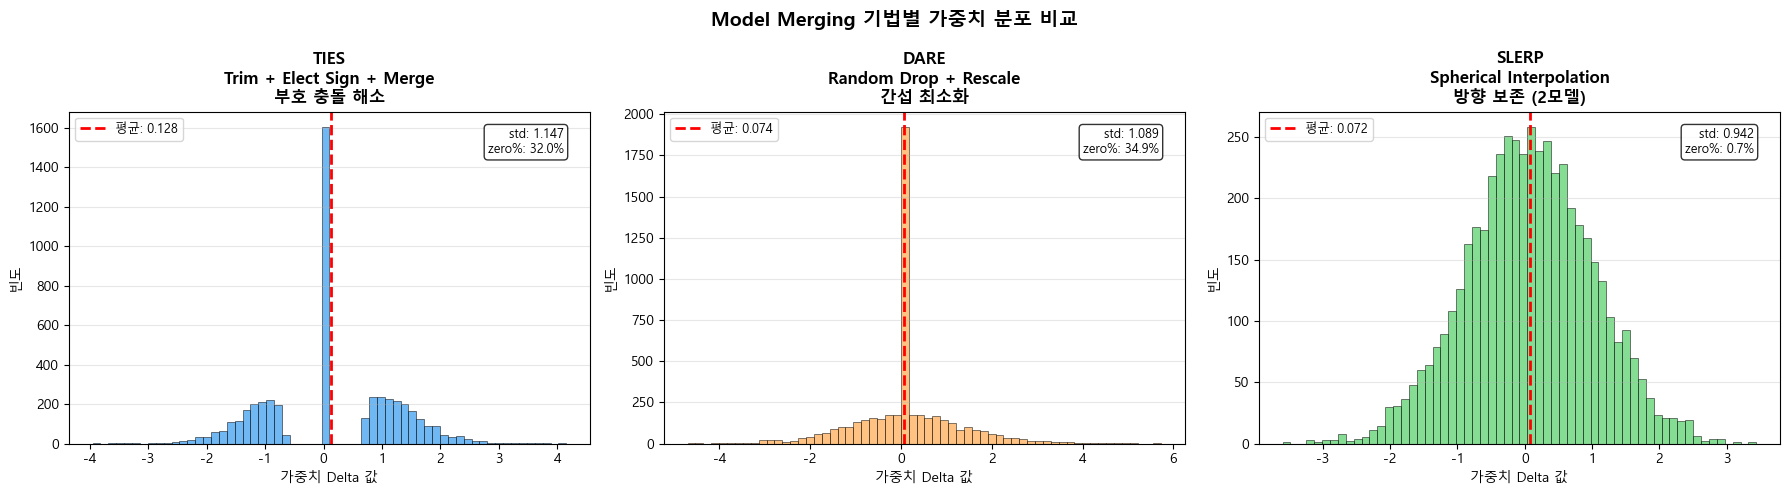


mergekit YAML 설정 예시 (TIES)

models:
  - model: math-expert/llama-7b-math
    parameters:
      density: 0.5        # top-k 비율
      weight: 1.0
  - model: code-expert/llama-7b-code
    parameters:
      density: 0.5
      weight: 0.8
  - model: chat-expert/llama-7b-chat
    parameters:
      density: 0.5
      weight: 0.6
merge_method: ties
base_model: meta-llama/Llama-2-7b-hf
parameters:
  normalize: true
dtype: float16

실행: mergekit-yaml config.yaml ./merged-model --cuda


In [3]:
# === Model Merging 시뮬레이션 ===
# 3개 모델의 가중치를 다양한 방법으로 병합, 결과 비교

np.random.seed(42)
n_params = 5000

# 3개 모델의 task vector (base model 대비 delta)
delta_math = np.random.normal(0.3, 1.0, n_params)    # 수학 모델
delta_code = np.random.normal(-0.2, 0.8, n_params)   # 코딩 모델
delta_chat = np.random.normal(0.1, 1.2, n_params)    # 대화 모델

# --- TIES Merging ---
def ties_merge(deltas, top_k=0.5):
    """TIES: Trim, Elect Sign, Merge"""
    result = np.zeros(deltas[0].shape)
    for i in range(len(result)):
        values = [d[i] for d in deltas]
        # Trim: 작은 값 제거
        threshold = np.percentile(np.abs(np.concatenate(deltas)), (1 - top_k) * 100)
        trimmed = [v if abs(v) > threshold else 0 for v in values]
        # Elect Sign: 다수결로 부호 결정
        signs = [np.sign(v) for v in trimmed if v != 0]
        if len(signs) == 0:
            result[i] = 0
            continue
        elected_sign = np.sign(sum(signs))
        # Merge: 같은 부호만 평균
        same_sign = [v for v in trimmed if np.sign(v) == elected_sign]
        result[i] = np.mean(same_sign) if same_sign else 0
    return result

# --- DARE Merging ---
def dare_merge(deltas, drop_rate=0.7):
    """DARE: Drop And REscale"""
    result = np.zeros(deltas[0].shape)
    for d in deltas:
        mask = np.random.random(d.shape) > drop_rate
        scaled = d * mask / (1 - drop_rate)  # rescale to preserve expectation
        result += scaled
    return result / len(deltas)

# --- SLERP (2개 모델만) ---
def slerp_merge(d1, d2, t=0.5):
    """SLERP: Spherical Linear Interpolation"""
    d1_norm = d1 / (np.linalg.norm(d1) + 1e-8)
    d2_norm = d2 / (np.linalg.norm(d2) + 1e-8)
    cos_omega = np.clip(np.dot(d1_norm, d2_norm), -1, 1)
    omega = np.arccos(cos_omega)
    if np.abs(np.sin(omega)) < 1e-8:
        return (1 - t) * d1 + t * d2
    s1 = np.sin((1 - t) * omega) / np.sin(omega)
    s2 = np.sin(t * omega) / np.sin(omega)
    return s1 * d1 + s2 * d2

merged_ties = ties_merge([delta_math, delta_code, delta_chat])
merged_dare = dare_merge([delta_math, delta_code, delta_chat])
merged_slerp = slerp_merge(delta_math, delta_code, t=0.5)  # 2개만

# --- 3-Panel Histogram 시각화 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = ['TIES', 'DARE', 'SLERP']
merged_results = [merged_ties, merged_dare, merged_slerp]
colors = ['#339af0', '#ffa94d', '#51cf66']
descriptions = [
    'Trim + Elect Sign + Merge\n부호 충돌 해소',
    'Random Drop + Rescale\n간섭 최소화',
    'Spherical Interpolation\n방향 보존 (2모델)'
]

for ax, method, merged, color, desc in zip(axes, methods, merged_results, colors, descriptions):
    ax.hist(merged, bins=60, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(x=np.mean(merged), color='red', linestyle='--', linewidth=2, label=f'평균: {np.mean(merged):.3f}')
    ax.set_title(f'{method}\n{desc}', fontsize=12, fontweight='bold')
    ax.set_xlabel('가중치 Delta 값')
    ax.set_ylabel('빈도')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    # 통계 정보
    stats_text = f'std: {np.std(merged):.3f}\nzero%: {np.mean(np.abs(merged) < 0.01)*100:.1f}%'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Model Merging 기법별 가중치 분포 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- mergekit YAML config 예시 ---
print("\n" + "=" * 60)
print("mergekit YAML 설정 예시 (TIES)")
print("=" * 60)
yaml_config = """
models:
  - model: math-expert/llama-7b-math
    parameters:
      density: 0.5        # top-k 비율
      weight: 1.0
  - model: code-expert/llama-7b-code
    parameters:
      density: 0.5
      weight: 0.8
  - model: chat-expert/llama-7b-chat
    parameters:
      density: 0.5
      weight: 0.6
merge_method: ties
base_model: meta-llama/Llama-2-7b-hf
parameters:
  normalize: true
dtype: float16
"""
print(yaml_config)
print("실행: mergekit-yaml config.yaml ./merged-model --cuda")

---
## 3. Knowledge Distillation (지식 증류)

큰 모델(Teacher)의 **출력 분포**를 작은 모델(Student)이 학습하여, 작은 모델로도 큰 모델에 근접한 성능을 달성하는 기법이다.

```
Teacher Model (70B, 고성능)  →  Soft Labels [0.7, 0.2, 0.05, 0.05]
        ↕ KL Divergence Loss (분포 차이 최소화)
Student Model (7B, 학습 대상) →  Student 출력 [0.5, 0.3, 0.1, 0.1]
```

### Soft Label vs Hard Label

| 라벨 종류 | 예시 | 정보량 |
|-----------|------|--------|
| Hard Label | [1, 0, 0, 0] | 정답만 알려줌 |
| Soft Label | [0.7, 0.2, 0.05, 0.05] | "정답은 A이지만 B도 약간 가능하다"는 **관계 정보** 포함 |

Soft Label에는 **클래스 간 유사도 정보**가 담겨 있다. "고양이"를 예측할 때 "호랑이"에 0.15 확률이 있다면, 두 개념이 유사하다는 Teacher의 지식이다.

### Distillation Temperature

Temperature(T)를 높이면 확률 분포가 부드러워져서 더 많은 관계 정보를 Student에게 전달할 수 있다.

| Temperature | 분포 | 효과 |
|-------------|------|------|
| T = 1 | 원본 그대로 | 기본 |
| T = 2~5 | 부드러움 (soft) | 관계 정보 최대 전달 |
| T > 10 | 균등 분포에 가까움 | 정보 희석 |

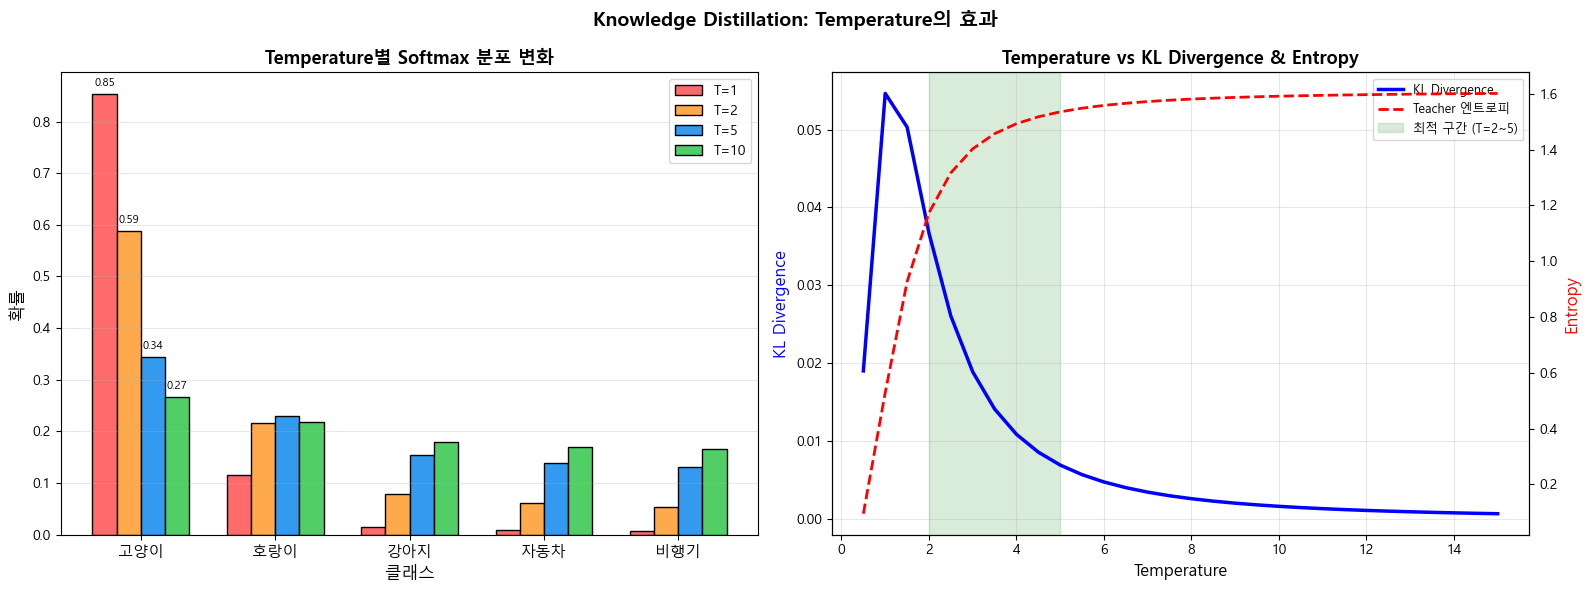

해석:
  T=1: 분포가 sharp → 정답 클래스만 강조, 관계 정보 부족
  T=2~5: 분포가 soft → 클래스 간 유사도 정보가 Student에게 전달
  T>10: 분포가 uniform에 가까움 → 정보가 희석되어 학습 효과 감소

  T=1 KL: 0.0546 | T=3 KL: 0.0189 | T=10 KL: 0.0017


In [4]:
# === Distillation 시뮬레이션 ===
# Temperature에 따른 softmax 분포 변화 + KL divergence 계산

def softmax_with_temperature(logits, T):
    """Temperature가 적용된 softmax"""
    scaled = logits / T
    exp_vals = np.exp(scaled - np.max(scaled))  # numerical stability
    return exp_vals / np.sum(exp_vals)

def kl_divergence(p, q):
    """KL(P || Q): P가 Teacher, Q가 Student"""
    p = np.clip(p, 1e-10, 1)
    q = np.clip(q, 1e-10, 1)
    return np.sum(p * np.log(p / q))

# Teacher의 logits (원본 출력)
teacher_logits = np.array([5.0, 3.0, 1.0, 0.5, 0.2])
class_names = ['고양이', '호랑이', '강아지', '자동차', '비행기']

temperatures = [1, 2, 5, 10]

# --- 2-Panel 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Temperature별 softmax 분포 변화
x = np.arange(len(class_names))
width = 0.18
colors_t = ['#ff6b6b', '#ffa94d', '#339af0', '#51cf66']

for i, (T, color) in enumerate(zip(temperatures, colors_t)):
    probs = softmax_with_temperature(teacher_logits, T)
    bars = axes[0].bar(x + i * width, probs, width, label=f'T={T}', color=color, edgecolor='black')
    # 가장 높은 bar에만 값 표시
    max_idx = np.argmax(probs)
    axes[0].text(x[max_idx] + i * width, probs[max_idx] + 0.01,
                 f'{probs[max_idx]:.2f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xlabel('클래스', fontsize=12)
axes[0].set_ylabel('확률', fontsize=12)
axes[0].set_title('Temperature별 Softmax 분포 변화', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(class_names, fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Temperature별 KL Divergence
# Student logits (Teacher보다 약간 다른 분포)
student_logits = np.array([4.0, 2.5, 1.5, 0.8, 0.3])

temp_range = np.arange(0.5, 15.1, 0.5)
kl_values = []
entropy_values = []

for T in temp_range:
    teacher_probs = softmax_with_temperature(teacher_logits, T)
    student_probs = softmax_with_temperature(student_logits, T)
    kl_values.append(kl_divergence(teacher_probs, student_probs))
    entropy_values.append(-np.sum(teacher_probs * np.log(teacher_probs + 1e-10)))

ax2_twin = axes[1].twinx()

line1, = axes[1].plot(temp_range, kl_values, 'b-', linewidth=2.5, label='KL Divergence')
line2, = ax2_twin.plot(temp_range, entropy_values, 'r--', linewidth=2, label='Teacher 엔트로피')

axes[1].set_xlabel('Temperature', fontsize=12)
axes[1].set_ylabel('KL Divergence', fontsize=12, color='blue')
ax2_twin.set_ylabel('Entropy', fontsize=12, color='red')
axes[1].set_title('Temperature vs KL Divergence & Entropy', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 최적 구간 표시
axes[1].axvspan(2, 5, alpha=0.15, color='green', label='최적 구간 (T=2~5)')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
labels.append('최적 구간 (T=2~5)')
lines.append(mpatches.Patch(color='green', alpha=0.15))
axes[1].legend(lines, labels, fontsize=9, loc='upper right')

plt.suptitle('Knowledge Distillation: Temperature의 효과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("해석:")
print("  T=1: 분포가 sharp → 정답 클래스만 강조, 관계 정보 부족")
print("  T=2~5: 분포가 soft → 클래스 간 유사도 정보가 Student에게 전달")
print("  T>10: 분포가 uniform에 가까움 → 정보가 희석되어 학습 효과 감소")
print(f"\n  T=1 KL: {kl_values[1]:.4f} | T=3 KL: {kl_values[5]:.4f} | T=10 KL: {kl_values[19]:.4f}")

---
## 4. Curriculum Learning (커리큘럼 학습)

인간이 쉬운 것부터 어려운 것 순서로 학습하듯, 모델에게도 **학습 데이터의 난이도 순서를 제어**하여 학습 효율과 최종 성능을 높이는 기법이다.

```
Phase 1 (쉬운 데이터: 짧은 문장, 단순 태스크)
  → Phase 2 (보통 데이터: 복합 질문, 중간 길이)
    → Phase 3 (어려운 데이터: 긴 추론, 모호한 태스크)
```

| 전략 | 순서 | 효과 |
|------|------|------|
| Easy-to-Hard | 쉬운 것 → 어려운 것 | 안정적 수렴, 일반적 추천 |
| Hard-to-Easy | 어려운 것 → 쉬운 것 | 특정 도메인에서 효과적 |
| Mixed + Pacing | 혼합하되 비율 조절 | 난이도 비율을 에폭별로 변경 |

### 난이도 측정 기준
- **문장 길이**: 짧은 문장 = 쉬움
- **모델 Loss**: 현재 모델의 Loss가 낮은 샘플 = 쉬움
- **레이블 복잡도**: 단순 분류 < 다중 레이블 < 자유 생성

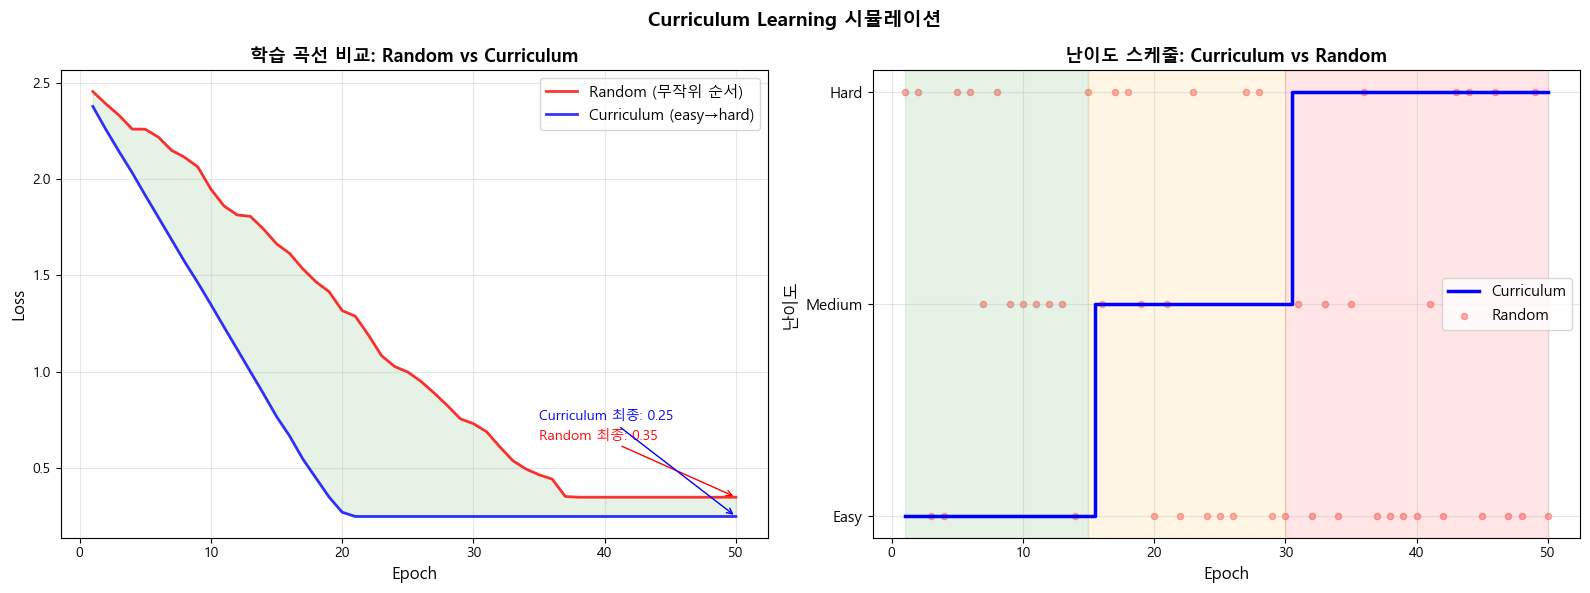

결과:
  Random 최종 Loss:     0.350
  Curriculum 최종 Loss: 0.250
  개선율: 28.6%

핵심: 같은 데이터, 같은 양 — 순서만 바꿨을 뿐인데 성능이 다르다


In [5]:
# === Curriculum Learning 시뮬레이션 ===
# Random vs Curriculum (easy→hard) 학습 곡선 비교

np.random.seed(42)

n_epochs = 50
n_samples = 1000

# 난이도별 데이터 (loss 기여도 시뮬레이션)
easy_loss_contrib = 0.3
medium_loss_contrib = 0.6
hard_loss_contrib = 1.0

# --- Random 학습: 매 에폭 난이도 섞여서 들어옴 ---
random_loss = []
loss_val = 2.5
for epoch in range(n_epochs):
    avg_difficulty = np.mean([easy_loss_contrib, medium_loss_contrib, hard_loss_contrib])
    noise = np.random.normal(0, 0.05)
    # 어려운 샘플이 초반에 섞여서 수렴이 불안정
    lr_effect = 0.08 * avg_difficulty * (1 + 0.3 * np.random.random())
    loss_val = max(0.35, loss_val - lr_effect + noise * avg_difficulty)
    random_loss.append(loss_val)

# --- Curriculum 학습: easy → medium → hard 순서 ---
curriculum_loss = []
loss_val = 2.5
for epoch in range(n_epochs):
    # 난이도 스케줄: 점진적으로 어려워짐
    progress = epoch / n_epochs
    if progress < 0.3:
        difficulty = easy_loss_contrib
    elif progress < 0.6:
        difficulty = medium_loss_contrib
    else:
        difficulty = hard_loss_contrib
    noise = np.random.normal(0, 0.03)
    # 쉬운 것부터 배우니 초반 수렴이 빠르고 안정적
    lr_effect = 0.12 * (1 - 0.3 * difficulty) * (1 + 0.1 * np.random.random())
    loss_val = max(0.25, loss_val - lr_effect + noise * difficulty * 0.5)
    curriculum_loss.append(loss_val)

# --- 2-Panel 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: 학습 곡선 비교
epochs = range(1, n_epochs + 1)
axes[0].plot(epochs, random_loss, 'r-', linewidth=2, alpha=0.8, label='Random (무작위 순서)')
axes[0].plot(epochs, curriculum_loss, 'b-', linewidth=2, alpha=0.8, label='Curriculum (easy→hard)')
axes[0].fill_between(epochs, random_loss, curriculum_loss, alpha=0.1, color='green')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('학습 곡선 비교: Random vs Curriculum', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 최종 Loss 표시
axes[0].annotate(f'Random 최종: {random_loss[-1]:.2f}', xy=(n_epochs, random_loss[-1]),
                 xytext=(n_epochs - 15, random_loss[-1] + 0.3),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')
axes[0].annotate(f'Curriculum 최종: {curriculum_loss[-1]:.2f}', xy=(n_epochs, curriculum_loss[-1]),
                 xytext=(n_epochs - 15, curriculum_loss[-1] + 0.5),
                 arrowprops=dict(arrowstyle='->', color='blue'), fontsize=10, color='blue')

# Panel 2: 난이도 스케줄 시각화
curriculum_difficulty = []
random_difficulty = []
for epoch in range(n_epochs):
    progress = epoch / n_epochs
    if progress < 0.3:
        curriculum_difficulty.append(1)  # Easy
    elif progress < 0.6:
        curriculum_difficulty.append(2)  # Medium
    else:
        curriculum_difficulty.append(3)  # Hard
    random_difficulty.append(np.random.choice([1, 2, 3]))

axes[1].step(epochs, curriculum_difficulty, 'b-', linewidth=2.5, label='Curriculum', where='mid')
axes[1].scatter(epochs, random_difficulty, c='red', alpha=0.3, s=20, label='Random')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('난이도', fontsize=12)
axes[1].set_title('난이도 스케줄: Curriculum vs Random', fontsize=13, fontweight='bold')
axes[1].set_yticks([1, 2, 3])
axes[1].set_yticklabels(['Easy', 'Medium', 'Hard'], fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# 구간 배경색
axes[1].axvspan(1, n_epochs * 0.3, alpha=0.1, color='green')
axes[1].axvspan(n_epochs * 0.3, n_epochs * 0.6, alpha=0.1, color='orange')
axes[1].axvspan(n_epochs * 0.6, n_epochs, alpha=0.1, color='red')

plt.suptitle('Curriculum Learning 시뮬레이션', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

improvement = ((random_loss[-1] - curriculum_loss[-1]) / random_loss[-1]) * 100
print(f"결과:")
print(f"  Random 최종 Loss:     {random_loss[-1]:.3f}")
print(f"  Curriculum 최종 Loss: {curriculum_loss[-1]:.3f}")
print(f"  개선율: {improvement:.1f}%")
print(f"\n핵심: 같은 데이터, 같은 양 — 순서만 바꿨을 뿐인데 성능이 다르다")

---
## 5. 기법 선택 의사결정 트리

문제 상황에 따라 4가지 기법 중 어떤 것을 선택할지 결정하는 프레임워크.

```
문제 상황 파악
  ├── 모델이 도메인 지식 자체가 부족? → YES → Continued Pre-training
  └── NO
       ├── 여러 모델의 강점을 합치고 싶다? → YES → Model Merging
       └── NO
            ├── 큰 모델 성능을 작은 모델로? → YES → Distillation
            └── NO → Curriculum Learning (학습 순서 최적화)
```

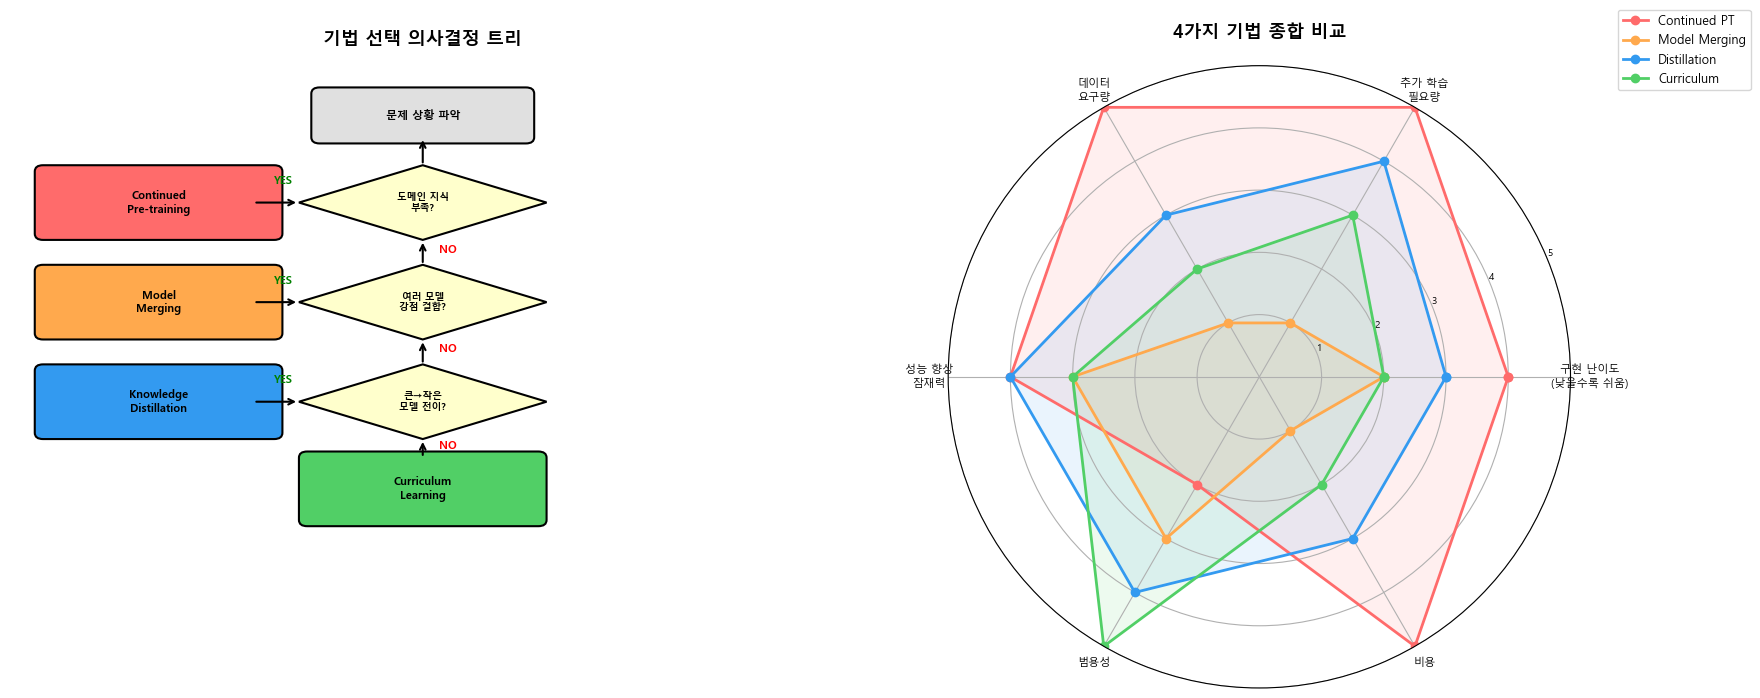

기법별 핵심 선택 기준:
  Continued PT:  도메인 지식이 아예 부족할 때 (비용 높음, 효과 확실)
  Model Merging: 추가 학습 없이 빠르게 결합할 때 (비용 최저)
  Distillation:  대형 모델 → 소형 모델 전이할 때 (배포 최적화)
  Curriculum:    같은 데이터로 효율을 높일 때 (가장 범용적)


In [6]:
# === 의사결정 트리 + 4기법 종합 비교 Radar Chart ===

fig = plt.figure(figsize=(18, 7))

# --- Panel 1: 의사결정 트리 (matplotlib 박스 + 화살표) ---
ax1 = fig.add_subplot(121)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('기법 선택 의사결정 트리', fontsize=13, fontweight='bold', pad=15)

# 박스 그리기 함수
def draw_box(ax, x, y, text, color, width=2.8, height=1.0):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                          boxstyle="round,pad=0.1", facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=8, fontweight='bold')

def draw_diamond(ax, x, y, text, color='#ffffcc'):
    diamond = plt.Polygon([(x, y+0.6), (x+1.5, y), (x, y-0.6), (x-1.5, y)],
                           facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(diamond)
    ax.text(x, y, text, ha='center', va='center', fontsize=7, fontweight='bold')

# Root
draw_box(ax1, 5, 9.2, '문제 상황 파악', '#e0e0e0', width=2.5, height=0.7)

# Decision 1
draw_diamond(ax1, 5, 7.8, '도메인 지식\n부족?')
ax1.annotate('', xy=(5, 8.85), xytext=(5, 8.4), arrowprops=dict(arrowstyle='->', lw=1.5))

# Yes → Continued PT
draw_box(ax1, 1.8, 7.8, 'Continued\nPre-training', '#ff6b6b')
ax1.annotate('', xy=(2.95, 7.8), xytext=(3.5, 7.8), arrowprops=dict(arrowstyle='<-', lw=1.5))
ax1.text(3.2, 8.1, 'YES', fontsize=8, color='green', fontweight='bold')

# Decision 2
draw_diamond(ax1, 5, 6.2, '여러 모델\n강점 결합?')
ax1.annotate('', xy=(5, 7.2), xytext=(5, 6.8), arrowprops=dict(arrowstyle='->', lw=1.5))
ax1.text(5.2, 7.0, 'NO', fontsize=8, color='red', fontweight='bold')

# Yes → Model Merging
draw_box(ax1, 1.8, 6.2, 'Model\nMerging', '#ffa94d')
ax1.annotate('', xy=(2.95, 6.2), xytext=(3.5, 6.2), arrowprops=dict(arrowstyle='<-', lw=1.5))
ax1.text(3.2, 6.5, 'YES', fontsize=8, color='green', fontweight='bold')

# Decision 3
draw_diamond(ax1, 5, 4.6, '큰→작은\n모델 전이?')
ax1.annotate('', xy=(5, 5.6), xytext=(5, 5.2), arrowprops=dict(arrowstyle='->', lw=1.5))
ax1.text(5.2, 5.4, 'NO', fontsize=8, color='red', fontweight='bold')

# Yes → Distillation
draw_box(ax1, 1.8, 4.6, 'Knowledge\nDistillation', '#339af0')
ax1.annotate('', xy=(2.95, 4.6), xytext=(3.5, 4.6), arrowprops=dict(arrowstyle='<-', lw=1.5))
ax1.text(3.2, 4.9, 'YES', fontsize=8, color='green', fontweight='bold')

# No → Curriculum Learning
draw_box(ax1, 5, 3.2, 'Curriculum\nLearning', '#51cf66')
ax1.annotate('', xy=(5, 4.0), xytext=(5, 3.7), arrowprops=dict(arrowstyle='->', lw=1.5))
ax1.text(5.2, 3.85, 'NO', fontsize=8, color='red', fontweight='bold')

# --- Panel 2: Radar Chart (4기법 종합 비교) ---
ax2 = fig.add_subplot(122, polar=True)

categories = ['구현 난이도\n(낮을수록 쉬움)', '추가 학습\n필요량', '데이터\n요구량',
              '성능 향상\n잠재력', '범용성', '비용']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# 각 기법 점수 (1~5)
techniques = {
    'Continued PT':    [4, 5, 5, 4, 2, 5],
    'Model Merging':   [2, 1, 1, 3, 3, 1],
    'Distillation':    [3, 4, 3, 4, 4, 3],
    'Curriculum':      [2, 3, 2, 3, 5, 2],
}
tech_colors = ['#ff6b6b', '#ffa94d', '#339af0', '#51cf66']

for (name, values), color in zip(techniques.items(), tech_colors):
    values_plot = values + values[:1]
    ax2.plot(angles, values_plot, 'o-', linewidth=2, label=name, color=color)
    ax2.fill(angles, values_plot, alpha=0.1, color=color)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=8)
ax2.set_ylim(0, 5)
ax2.set_yticks([1, 2, 3, 4, 5])
ax2.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=7)
ax2.set_title('4가지 기법 종합 비교', fontsize=13, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.show()

print("기법별 핵심 선택 기준:")
print("  Continued PT:  도메인 지식이 아예 부족할 때 (비용 높음, 효과 확실)")
print("  Model Merging: 추가 학습 없이 빠르게 결합할 때 (비용 최저)")
print("  Distillation:  대형 모델 → 소형 모델 전이할 때 (배포 최적화)")
print("  Curriculum:    같은 데이터로 효율을 높일 때 (가장 범용적)")

---
## 6. 핵심 정리

| 기법 | 핵심 | 적용 시점 |
|------|------|----------|
| **Continued Pre-training** | 도메인 코퍼스로 사전학습 연장 | 모델이 도메인 용어/지식 자체를 모를 때 |
| **Model Merging** | 가중치 직접 병합 (TIES/DARE/SLERP) | 여러 Expert 모델의 강점을 합칠 때 |
| **Distillation** | Teacher → Student 지식 전이 | 대형 모델 성능을 소형 모델로 옮길 때 |
| **Curriculum Learning** | 학습 데이터 난이도 순서 제어 | 같은 데이터로 학습 효율을 높일 때 |

### 실전 조합 시나리오 (의료 AI 챗봇)

```
Step 1: Continued Pre-training (의료 논문 + 가이드라인 → 도메인 지식 주입)
Step 2: SFT (의료 QA 데이터셋 → 태스크 학습)
Step 3: DPO (의사 선호도 데이터 → 정렬)
Step 4: Distillation (70B → 7B → 배포용 경량화)
Step 5: Model Merging (+ 일반 대화 모델 병합 → 범용성 확보)
```

### 핵심 원칙

> **학습 데이터를 바꾸기 전에, 학습 방법을 바꿔라.** 같은 1만 개의 데이터도 Curriculum Learning으로 순서를 바꾸면 성능이 달라지고, Distillation으로 70B의 지식을 담으면 7B가 달라진다. 데이터를 더 모으는 것은 가장 마지막 수단이다.

In [7]:
# === Phase 9-2 체크포인트 ===

checkpoints = [
    ("Continued Pre-training과 Fine-tuning의 목적 차이를 설명할 수 있는가",
     "CPT = 도메인 지식 주입 (비구조화 텍스트), FT = 태스크 수행 능력 (instruction 쌍)"),
    ("어떤 상황에서 Continued Pre-training이 필요한지 판단할 수 있는가",
     "모델이 도메인 용어/개념 자체를 모를 때 (의료, 법률, 금융 등)"),
    ("TIES, DARE, SLERP 각각의 병합 방식과 적합 상황을 구분할 수 있는가",
     "TIES=부호충돌해소(3+), DARE=랜덤드롭(3+유사), SLERP=구면보간(2개최고)"),
    ("Model Merging의 제약 조건 (같은 아키텍처)을 이해하는가",
     "같은 베이스 아키텍처만 가능, 병합 후 반드시 평가 필요"),
    ("Distillation에서 Soft Label이 Hard Label보다 유리한 이유를 설명할 수 있는가",
     "클래스 간 유사도 정보 포함 (고양이-호랑이 관계 등)"),
    ("KL Divergence Loss의 역할을 직관적으로 설명할 수 있는가",
     "Teacher와 Student의 출력 분포 차이를 최소화하는 손실 함수"),
    ("Curriculum Learning의 난이도 측정 기준을 3가지 이상 알고 있는가",
     "문장 길이, 모델 Loss, 레이블 복잡도"),
    ("주어진 시나리오에서 4가지 기법 중 적절한 것을 선택할 수 있는가",
     "의사결정 트리: 도메인지식부족→CPT, 모델결합→Merge, 경량화→Distill, 효율→Curriculum"),
]

print("=" * 70)
print("Phase 9-2 체크포인트: 고급 학습 기법")
print("=" * 70)

for i, (question, answer) in enumerate(checkpoints, 1):
    print(f"\n[{i}] {question}")
    print(f"    >>> {answer}")

print("\n" + "=" * 70)
print("핵심 원칙: 학습 데이터를 바꾸기 전에, 학습 방법을 바꿔라")
print("=" * 70)

Phase 9-2 체크포인트: 고급 학습 기법

[1] Continued Pre-training과 Fine-tuning의 목적 차이를 설명할 수 있는가
    >>> CPT = 도메인 지식 주입 (비구조화 텍스트), FT = 태스크 수행 능력 (instruction 쌍)

[2] 어떤 상황에서 Continued Pre-training이 필요한지 판단할 수 있는가
    >>> 모델이 도메인 용어/개념 자체를 모를 때 (의료, 법률, 금융 등)

[3] TIES, DARE, SLERP 각각의 병합 방식과 적합 상황을 구분할 수 있는가
    >>> TIES=부호충돌해소(3+), DARE=랜덤드롭(3+유사), SLERP=구면보간(2개최고)

[4] Model Merging의 제약 조건 (같은 아키텍처)을 이해하는가
    >>> 같은 베이스 아키텍처만 가능, 병합 후 반드시 평가 필요

[5] Distillation에서 Soft Label이 Hard Label보다 유리한 이유를 설명할 수 있는가
    >>> 클래스 간 유사도 정보 포함 (고양이-호랑이 관계 등)

[6] KL Divergence Loss의 역할을 직관적으로 설명할 수 있는가
    >>> Teacher와 Student의 출력 분포 차이를 최소화하는 손실 함수

[7] Curriculum Learning의 난이도 측정 기준을 3가지 이상 알고 있는가
    >>> 문장 길이, 모델 Loss, 레이블 복잡도

[8] 주어진 시나리오에서 4가지 기법 중 적절한 것을 선택할 수 있는가
    >>> 의사결정 트리: 도메인지식부족→CPT, 모델결합→Merge, 경량화→Distill, 효율→Curriculum

핵심 원칙: 학습 데이터를 바꾸기 전에, 학습 방법을 바꿔라
